```{contents}
```
## Autoencoders

Autoencoders are **neural network architectures** used to learn **efficient, compressed representations** of data — called **encodings** or **latent representations** — in an **unsupervised** manner.


An **autoencoder** learns:
$$
x ; \xrightarrow{\text{Encoder}} ; z ; \xrightarrow{\text{Decoder}} ; \hat{x}
$$

where:

* $x$: original input
* $z$: encoded latent representation (compressed form)
* $\hat{x}$: reconstructed output (should be as close to $x$ as possible)

---

### Architecture

It consists of **three parts**:

![alt text](image.png)

#### (a) Encoder

* Maps the input $x$ to a **latent vector $z$**.
* Gradually **reduces dimensionality**.
* Learns the **most relevant features**.

$$
z = f_{\text{encoder}}(x) = \sigma(Wx + b)
$$

---

#### (b) Latent Space (Bottleneck)

* The **compressed representation** of the input.
* Acts as an **information bottleneck**:
  only the most meaningful features pass through.

The dimension of $z$ is **much smaller** than $x$.

---

#### (c) Decoder

* Reconstructs the input from $z$.
* Tries to **reverse** the encoding process.

$$
\hat{x} = f_{\text{decoder}}(z) = \sigma(W'z + b')
$$

The output $\hat{x}$ should be **as close as possible** to the input $x$.

---

### **3. Objective Function**

The goal is to **minimize reconstruction loss**:

$$
L(x, \hat{x}) = ||x - \hat{x}||^2
$$
or, for images,
$$
L = \frac{1}{N} \sum_i (x_i - \hat{x}_i)^2
$$

If inputs are probabilistic (e.g., grayscale pixels between 0 and 1),
cross-entropy loss can also be used.

---

### **4. Intuition**

Autoencoders **don’t memorize data** —
they learn **compact patterns** that can explain it efficiently.

Example:

* Input: a 28×28 grayscale image (784 pixels)
* Encoder compresses to 32 numbers (latent vector)
* Decoder reconstructs the image from those 32 numbers
  If the reconstruction is close to the original, the model has **learned meaningful features**.

---

### Variants of Autoencoders

#### **Undercomplete Autoencoder**

* Bottleneck dimension < input dimension.
* Forces network to learn **compressed** features.

👉 Common for dimensionality reduction.

---

#### **Denoising Autoencoder**

* Input is **corrupted** (noise added).
* Network must **reconstruct the clean version**.

$$
\text{Input: noisy } x' \Rightarrow \text{Output: clean } x
$$

👉 Forces network to learn **robust representations**.

---

#### **Sparse Autoencoder**

* Adds a **sparsity constraint** on hidden neurons.
* Only a few neurons activate for any given input.

$$
L_{\text{total}} = L_{\text{reconstruction}} + \lambda \sum_j |a_j|
$$

👉 Encourages features that are **disentangled** and **interpretable**.

---

#### **Contractive Autoencoder**

* Adds a penalty on gradients of hidden activations w.r.t. inputs.
* Makes the representation **resistant to small perturbations**.

$$
L_{\text{total}} = L_{\text{reconstruction}} + \lambda ||\nabla_x h(x)||^2
$$

👉 Increases robustness to noise.

---

#### **Variational Autoencoder (VAE)**

* A **probabilistic** version of autoencoder.
* Learns a **distribution** over the latent space, not just fixed points.

Encoder outputs mean (μ) and variance (σ) vectors:
$$
z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$

Loss = reconstruction loss + KL divergence (regularization).

👉 Used in **generative modeling** (e.g., image synthesis).

---

#### **Convolutional Autoencoder (CAE)**

* Uses convolutional layers for encoding and decoding.
* Works better for image data by capturing spatial patterns.

👉 Used for denoising and dimensionality reduction in vision.

---

#### **Sequence Autoencoder**

* Uses **RNNs (LSTM/GRU)** for sequential data (text, time series).
* Encoder compresses sequence → context vector
* Decoder reconstructs sequence from context

👉 Used in NLP tasks.

---

### Applications

| Domain                 | Application                                     |
| ---------------------- | ----------------------------------------------- |
| 📷 Computer Vision     | Image denoising, compression, anomaly detection |
| 💬 NLP                 | Sentence embedding, language model pretraining  |
| 📊 Data Compression    | Dimensionality reduction (like PCA)             |
| ⚙️ Anomaly Detection   | Learn “normal” patterns, detect deviations      |
| 🧬 Bioinformatics      | Gene expression encoding                        |
| 🧮 Generative Modeling | Image and music generation (VAE, GAN hybrids)  

✅ Unsupervised — no labels needed
✅ Learns non-linear features
✅ Dimensionality reduction better than PCA
✅ Useful for data compression, pretraining, and anomaly detection

---

### Limitations

❌ May just copy input if not properly regularized
❌ Latent space not always interpretable
❌ Not generative unless probabilistic (like VAE)
❌ Sensitive to overfitting and poor initialization

---

### Example in PyTorch (Simplified)


In [1]:
import torch
from torch import nn

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

model = Autoencoder()

In [2]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True)

100%|██████████| 9.91M/9.91M [00:05<00:00, 1.89MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 108kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 517kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.02MB/s]


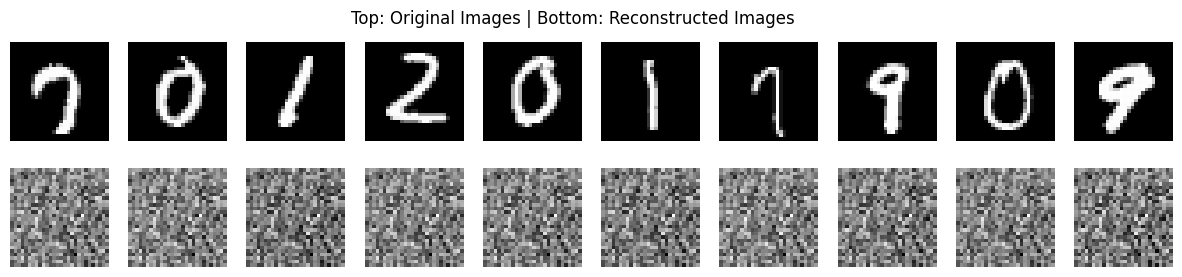

In [3]:
# Take a batch of test images
images, _ = next(iter(test_loader))
outputs = model(images)

# Plot original vs reconstructed images
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(images[i].view(28, 28).detach().numpy(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(outputs[i].view(28, 28).detach().numpy(), cmap='gray')
    axes[1, i].axis('off')

plt.suptitle("Top: Original Images | Bottom: Reconstructed Images")
plt.show()


Training uses **MSE loss** and **Adam optimizer** to minimize:

$$
\text{Loss} = ||x - \hat{x}||^2
$$

---

### Visualization (Conceptual)

```
        ┌────────────────────────────────────────┐
        │              AUTOENCODER               │
        └────────────────────────────────────────┘
 Input → [Encoder ↓] → [Latent Space] → [Decoder ↑] → Output
          ↓ Compress        |        Expand ↑
        Representation      |      Reconstruction
```

---

**In Summary**

| Component             | Role                                                |
| --------------------- | --------------------------------------------------- |
| **Encoder**           | Learns compressed representation                    |
| **Latent Vector (z)** | Holds the essential features                        |
| **Decoder**           | Reconstructs input from z                           |
| **Loss Function**     | Ensures reconstructed output ≈ input                |
| **Goal**              | Learn efficient, meaningful representations of data |

---

> **Autoencoders = Neural compression + reconstruction.**
> They learn the essence of your data by forcing the model to rebuild it from fewer dimensions.

